Saving Lung-Cancer-Screening-CT.jpg to Lung-Cancer-Screening-CT.jpg


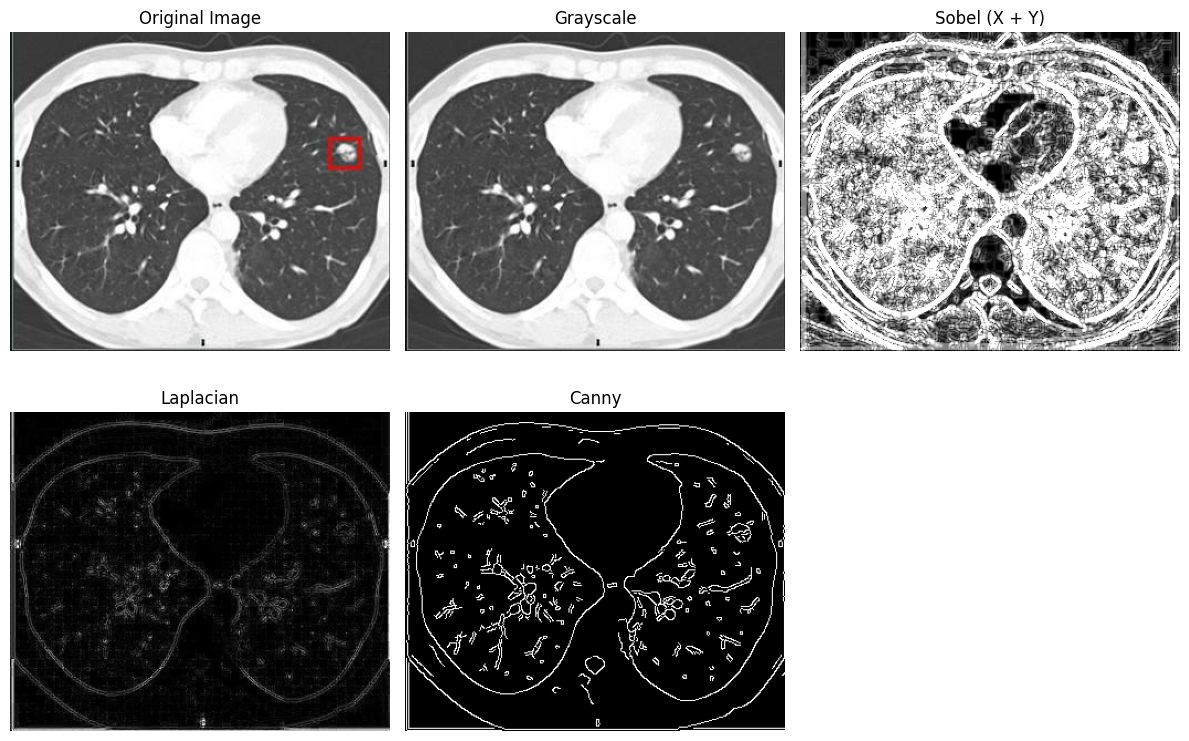

In [7]:
# Install required libraries (if not already installed)
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload Image
uploaded = files.upload()

# Get image filename
image_path = list(uploaded.keys())[0]




# Step 2: Read Image
img = cv2.imread(image_path)

# Convert BGR to RGB (for display)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 3: Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 4: Sobel Edge Detection
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

# Convert to absolute values
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

# Combine Sobel X and Y
sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

# Step 5: Laplacian Edge Detection
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

# Step 6: Canny Edge Detection
canny = cv2.Canny(gray, 100, 200)

# Step 7: Display Results
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sobel_combined, cmap='gray')
plt.title("Sobel (X + Y)")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(canny, cmap='gray')
plt.title("Canny")
plt.axis('off')

plt.tight_layout()
plt.show()